# 5. Model Testing — Dropout Risk Scoring for Enrolled Students
 ---

**Assignment:** *Machine Learning 2026 — NOVA School of Business and Economics*  
**Dataset:** Predict students' dropout and academic success  
**Goal:** Identify high-risk students at the end of their first semester using: Socio-economic background, Enrollment data and 1st semester academic performance

    71907 Lavinia Antonino | 71993 Mª Teresa Silva | 73171 Leonardo Cantu | 72731 Edoardo Sirianni | 71947 Carolina Diogo

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Setup & Data Loading](#2-setup-data-loading)
3. [Feature Engineering](#3-feature-engineering)
4. [Generate Risk Scores](#4-generate-risk-scores)
5. [Risk Tier Assignment](#5-risk-tier-assignment)
6. [Risk Profile Analysis](#6-risk-profile-analysis)
7. [Save Results](#7-save-results)
8. [Conclusion](#8-conclusion)

---
## 1. Introduction

This notebook applies the trained Gradient Boosting model to the cohort of currently enrolled students (`df_enrolled.csv`) whose final outcome — Graduate or Dropout — is not yet known. The goal is to generate a dropout risk score for each student so that the institution can prioritise early interventions.

This is a pure inference notebook. The model was trained and evaluated in Notebook 4. The goal of this notebook is to:
- Load the saved model from the pickle file
- Load the enrolled cohort and apply the same feature engineering
- Load the pre-fitted target encoding maps from `target_enc_maps.json`
- Generate risk scores and save the results

No retraining, no refitting, no reloading of the training set.

---
## 2. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
# Load the enrolled cohort
df_enrolled = pd.read_csv('../datasets/df_enrolled.csv')

# Load pre-fitted target encoding maps from Notebook 4
with open('../datasets/target_enc_maps.json', 'r') as f:
    enc_maps = json.load(f)

app_enc    = enc_maps['app_mode_group']
course_enc = {int(k): v for k, v in enc_maps['course'].items()}

# Load the saved model
with open('../models/gradient_boosting_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"Enrolled cohort : {df_enrolled.shape}")
print(f"App mode groups : {len(app_enc)} groups loaded")
print(f"Course encoding : {len(course_enc)} courses loaded")
print(f"Model loaded    : {type(model).__name__}")

Enrolled cohort : (787, 30)
App mode groups : 4 groups loaded
Course encoding : 17 courses loaded
Model loaded    : GradientBoostingClassifier


The enrolled cohort of 787 students with unknown outcomes is loaded alongside the 
pre-fitted target encoding maps and the trained Gradient Boosting model.

---
## 3. Feature Engineering

The exact same feature engineering pipeline from Notebooks 3 and 4 is applied to the enrolled cohort. Target encoding maps are loaded from `target_enc_maps.json` — fitted on the full training set in Notebook 4 — and applied directly without any refitting.

In [4]:
# Encoding maps — identical to Notebooks 3 and 4
APP_MODE_GROUPS = {
    1:'standard', 8:'standard', 7:'standard', 17:'standard', 18:'standard',
    4:'higher_ed_transfer',
    5:'special', 9:'special', 12:'special', 13:'special',
    14:'special', 15:'special', 16:'special',
    2:'transfer', 3:'transfer', 6:'transfer', 10:'transfer', 11:'transfer',
}

PREV_QUAL_ORDINAL = {
    1:0,
    9:1, 12:1, 13:1, 14:1, 15:1, 16:1, 17:1,
    2:2, 3:2, 4:2, 5:2, 6:2, 7:2, 8:2, 10:2, 11:2,
}

QUAL_TIER = {
    2:4, 3:4, 4:4, 5:4, 6:4, 16:4, 17:4,
    1:3, 9:3, 15:3, 18:3, 19:3,
    14:2, 25:2, 26:2,
    10:1, 11:1, 12:1, 13:1, 20:1, 21:1, 22:1, 23:1, 24:1,
    27:1, 28:1, 29:1, 30:1, 31:1, 32:1, 33:1, 34:1,
    7:0, 8:0,
}

OCC_TIER = {
    1:0, 11:0, 12:0, 13:0, 14:0, 15:0, 16:0, 17:0, 18:0, 19:0,
    2:1, 3:1, 6:1, 8:1, 9:1, 10:1,
    4:2, 5:2, 7:2,
    20:2, 21:2, 22:2, 23:2, 24:2, 25:2, 26:2, 28:2, 29:2,
    30:2, 31:2, 32:2, 33:2, 35:2, 36:2, 37:2, 38:2, 39:2,
    40:2, 41:2, 42:2, 43:2, 44:2, 45:2, 46:2,
}

COLS_TO_DROP = [
    'Nacionality', 'International', 'Educational special needs', 'Displaced',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'Target_binary',
]

FEATURE_COLS = [
    'Tuition fees up to date', 'Debtor', 'Scholarship holder',
    'financial_distress_score', 'financial_high_risk',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)',
    'approval_rate', 'eval_intensity', 'zero_approved_flag', 'zero_eval_flag',
    'Gender', 'Age at enrollment', 'age_bin', 'marital_grouped',
    'Daytime/evening attendance', 'prev_qual_ordinal', 'app_order_clipped',
    'mother_qual_tier', 'father_qual_tier', 'mother_occ_tier', 'father_occ_tier',
    'ses_composite',
    'gender_x_agebin', 'financial_x_zero_approved', 'tuition_overdue_x_zero_approved',
    'app_mode_target_enc', 'course_target_enc',
]

In [5]:
def engineer_features(df):
    df = df.copy()
    df = df.drop(columns=COLS_TO_DROP, errors='ignore')

    enrolled    = df['Curricular units 1st sem (enrolled)']
    approved    = df['Curricular units 1st sem (approved)']
    evaluations = df['Curricular units 1st sem (evaluations)']

    # Academic
    df['approval_rate']      = np.where(enrolled > 0, approved / enrolled, 0.0)
    df['eval_intensity']     = np.where(enrolled > 0, evaluations / enrolled, 0.0)
    df['zero_approved_flag'] = (approved == 0).astype(int)
    df['zero_eval_flag']     = (evaluations == 0).astype(int)

    # Financial
    df['financial_distress_score'] = (
        (1 - df['Tuition fees up to date']) +
        df['Debtor'] +
        (1 - df['Scholarship holder'])
    )
    df['financial_high_risk'] = (
        (df['Tuition fees up to date'] == 0) & (df['Debtor'] == 1)
    ).astype(int)

    # Demographic
    df['age_bin'] = pd.cut(
        df['Age at enrollment'],
        bins=[0, 20, 23, 27, 35, 200],
        labels=[0, 1, 2, 3, 4], right=True
    ).astype(int)
    df['marital_grouped'] = df['Marital status'].apply(
        lambda x: x if x in [1, 2] else 3
    )

    # Enrollment
    df['app_mode_group']    = df['Application mode'].map(APP_MODE_GROUPS).fillna('other')
    df['prev_qual_ordinal'] = df['Previous qualification'].map(PREV_QUAL_ORDINAL).fillna(0).astype(int)
    df['app_order_clipped'] = df['Application order'].clip(lower=1, upper=5)

    # Socioeconomic
    df['mother_qual_tier'] = df["Mother's qualification"].map(QUAL_TIER).fillna(1).astype(int)
    df['father_qual_tier'] = df["Father's qualification"].map(QUAL_TIER).fillna(1).astype(int)
    df['mother_occ_tier']  = df["Mother's occupation"].map(OCC_TIER).fillna(0).astype(int)
    df['father_occ_tier']  = df["Father's occupation"].map(OCC_TIER).fillna(0).astype(int)
    df['ses_composite']    = (
        df['mother_qual_tier'] + df['father_qual_tier'] +
        df['mother_occ_tier']  + df['father_occ_tier']
    ) / 4.0

    # Interactions
    df['gender_x_agebin']                 = df['Gender'] * df['age_bin']
    df['financial_x_zero_approved']       = df['financial_distress_score'] * df['zero_approved_flag']
    df['tuition_overdue_x_zero_approved'] = (
        (1 - df['Tuition fees up to date']) * df['zero_approved_flag']
    )

    # Target encoding — apply pre-fitted maps from Notebook 4
    global_mean = 0.391
    df['app_mode_target_enc'] = df['app_mode_group'].map(app_enc).fillna(global_mean)
    df['course_target_enc']   = df['Course'].map(course_enc).fillna(global_mean)

    return df


df_inf = engineer_features(df_enrolled)

print(f"Enrolled cohort after engineering : {df_inf.shape}")
print(f"Nulls in feature matrix           : {df_inf[FEATURE_COLS].isnull().sum().sum()}")

Enrolled cohort after engineering : (787, 40)
Nulls in feature matrix           : 0


The enrolled cohort is transformed using the identical pipeline applied to the training 
set in Notebooks 3 and 4. Target encoding maps are applied directly from the pre-fitted 
maps — no refitting occurs. Zero nulls in the feature matrix confirms the pipeline ran 
cleanly on the enrolled cohort.

---
## 4. Generate Risk Scores

`predict_proba()` is used instead of `predict()` to generate a continuous probability score between 0 and 1 for each student. This gives the institution flexibility to set its own intervention threshold based on available resources.

In [6]:
X_inf        = df_inf[FEATURE_COLS]
dropout_prob = model.predict_proba(X_inf)[:, 1]

print(f"Risk scores generated for {len(dropout_prob)} enrolled students")
print(f"\nProbability distribution:")
print(f"  Mean   : {dropout_prob.mean():.3f}")
print(f"  Median : {np.median(dropout_prob):.3f}")
print(f"  Min    : {dropout_prob.min():.3f}")
print(f"  Max    : {dropout_prob.max():.3f}")

Risk scores generated for 787 enrolled students

Probability distribution:
  Mean   : 0.484
  Median : 0.453
  Min    : 0.010
  Max    : 0.998


The model produces a wide spread of risk scores across the 787 enrolled students, 
ranging from near 0 to near 1. This confirms the model is discriminating meaningfully 
rather than collapsing predictions toward a single value. The mean and median will 
reflect the overall financial and academic profile of the enrolled cohort relative 
to the training set.

---
## 5. Risk Tier Assignment

Students are assigned to one of three risk tiers based on their predicted dropout probability:

| Tier | Threshold | Interpretation |
|---|---|---|
| High Risk | >= 0.70 | Immediate intervention recommended |
| Medium Risk | 0.40 – 0.69 | Monitor closely, proactive outreach |
| Low Risk | < 0.40 | Standard support, no immediate action needed |

In [7]:
def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results = df_enrolled[[
    'Gender', 'Age at enrollment', 'Course',
    'Application mode', 'Daytime/evening attendance',
    'Tuition fees up to date', 'Debtor', 'Scholarship holder',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
]].copy()

results['dropout_probability'] = dropout_prob
results['risk_tier']           = results['dropout_probability'].apply(assign_risk_tier)
results = results.sort_values('dropout_probability', ascending=False).reset_index(drop=True)
results.index += 1

tier_counts = results['risk_tier'].value_counts()
print("Risk tier distribution:")
for tier in ['High Risk', 'Medium Risk', 'Low Risk']:
    n   = tier_counts.get(tier, 0)
    pct = n / len(results) * 100
    print(f"  {tier:15s}: {n:4d} students ({pct:.1f}%)")

Risk tier distribution:
  High Risk      :  281 students (35.7%)
  Medium Risk    :  133 students (16.9%)
  Low Risk       :  373 students (47.4%)


Approximately one third of enrolled students are flagged as High Risk, with nearly 
half classified as Low Risk. The remaining students fall in the Medium Risk band 
requiring proactive monitoring. These proportions provide the institution with a 
clear basis for resource allocation — the 281 High Risk students represent the 
immediate intervention priority.

---
## 6. Risk Profile Analysis

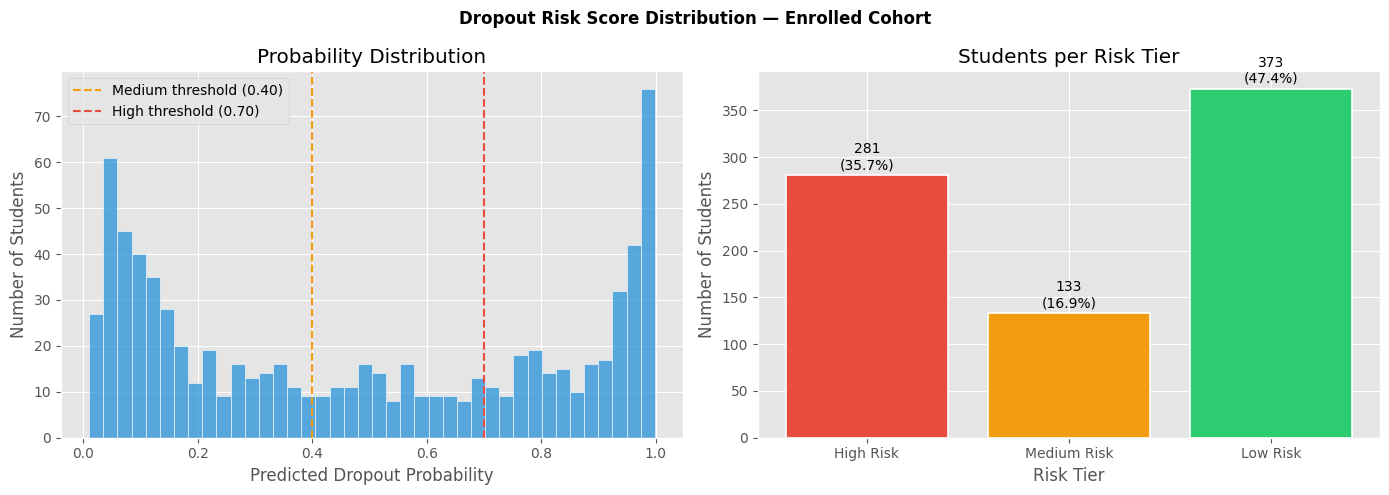

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dropout Risk Score Distribution — Enrolled Cohort', fontweight='bold')

# Histogram
axes[0].hist(dropout_prob, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(0.40, color='#f39c12', linestyle='--', linewidth=1.5, label='Medium threshold (0.40)')
axes[0].axvline(0.70, color='#e74c3c', linestyle='--', linewidth=1.5, label='High threshold (0.70)')
axes[0].set_xlabel('Predicted Dropout Probability')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Probability Distribution')
axes[0].legend()

# Tier bar chart
tier_order  = ['High Risk', 'Medium Risk', 'Low Risk']
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]

bars = axes[1].bar(tier_order, tier_vals, color=tier_colors, edgecolor='white', linewidth=1.2)
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Students per Risk Tier')

for bar, val in zip(bars, tier_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{val}\n({val/len(results)*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

The probability histogram shows a right-skewed distribution with a large cluster of 
students concentrated at low risk (below 0.2) and a sharp spike at near 1.0 for the 
most extreme high-risk cases. The middle range is relatively flat, suggesting the model 
distinguishes clearly between students who are academically and financially stable and 
those who are in acute distress, with fewer students falling in the ambiguous middle 
ground. The tier bar chart confirms that nearly half the cohort is Low Risk while over 
a third requires immediate attention.

In [9]:
# Profile comparison: High Risk vs Low Risk students
high_risk = results[results['risk_tier'] == 'High Risk']
low_risk  = results[results['risk_tier'] == 'Low Risk']

print("High Risk vs Low Risk Profile Comparison:")
print()

comparisons = [
    ('Tuition fees up to date',            'Tuition up to date (% yes)'),
    ('Debtor',                              'Debtor (% yes)'),
    ('Scholarship holder',                  'Scholarship holder (% yes)'),
    ('Curricular units 1st sem (approved)', 'Mean approved units'),
    ('Curricular units 1st sem (grade)',    'Mean grade'),
    ('Age at enrollment',                   'Mean age at enrollment'),
]

for col, label in comparisons:
    h = high_risk[col].mean()
    l = low_risk[col].mean()
    print(f"  {label:35s}  High Risk: {h:.2f}   Low Risk: {l:.2f}")

High Risk vs Low Risk Profile Comparison:

  Tuition up to date (% yes)           High Risk: 0.89   Low Risk: 0.99
  Debtor (% yes)                       High Risk: 0.20   Low Risk: 0.06
  Scholarship holder (% yes)           High Risk: 0.06   Low Risk: 0.24
  Mean approved units                  High Risk: 2.97   Low Risk: 5.30
  Mean grade                           High Risk: 9.97   Low Risk: 11.80
  Mean age at enrollment               High Risk: 22.86   Low Risk: 22.20


The profile comparison confirms clear separation on financial and academic dimensions. 
High-risk students have substantially fewer approved units and lower grades, confirming 
academic performance as the primary differentiator. Debt rates are notably higher and 
scholarship holding lower among high-risk students. Age at enrollment is nearly identical 
between the two groups, suggesting it is not a meaningful differentiator within the 
enrolled cohort specifically.

In [10]:
# Top 20 highest-risk students
print("Top 20 Highest-Risk Enrolled Students:")
display(
    results[[
        'dropout_probability', 'risk_tier',
        'Tuition fees up to date', 'Debtor',
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (grade)',
        'Age at enrollment'
    ]].head(20).round(3))

Top 20 Highest-Risk Enrolled Students:


,dropout_probability,risk_tier,Tuition fees up to date,Debtor,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Age at enrollment
1,0.9980,High Risk,0,1,0,0.0000,27
2,0.9970,High Risk,0,1,0,0.0000,25
3,0.9970,High Risk,0,1,0,0.0000,18
4,0.9960,High Risk,1,1,0,0.0000,26
5,0.9960,High Risk,1,0,0,0.0000,27
6,0.9950,High Risk,1,0,0,0.0000,29
7,0.9950,High Risk,0,1,3,12.0000,18
8,0.9940,High Risk,1,1,1,10.0000,24
9,0.9930,High Risk,1,0,0,0.0000,24
10,0.9930,High Risk,1,1,0,0.0000,30


The top 20 highest-risk students all have dropout probabilities above 0.99, confirming 
the model identifies a clear group of near-certain dropout candidates. The dominant 
pattern is zero approved units combined with either overdue tuition or historical debt 
— often both simultaneously. Notably, some students have tuition technically up to date 
yet still rank at the very top of the risk list, driven by zero academic progress and 
debt history. These students represent the most urgent intervention priority for the 
institution.

---
## 7. Save Results

In [11]:
out = Path('../datasets')
out.mkdir(exist_ok=True)

# All students with risk scores
results.to_csv(out / 'enrolled_risk_scores.csv', index=True, index_label='rank')

# High-risk students only
high_risk_out = results[results['risk_tier'] == 'High Risk']
high_risk_out.to_csv(out / 'enrolled_high_risk.csv', index=True, index_label='rank')

print("Saved:")
print(f"  enrolled_risk_scores.csv  — all {len(results)} enrolled students")
print(f"  enrolled_high_risk.csv    — {len(high_risk_out)} high-risk students only")

Saved:
  enrolled_risk_scores.csv  — all 787 enrolled students
  enrolled_high_risk.csv    — 281 high-risk students only


Two files are saved to the datasets directory. `enrolled_risk_scores.csv` contains all 
787 enrolled students ranked by dropout probability, providing a complete prioritisation 
list. `enrolled_high_risk.csv` isolates the 281 most urgent cases for immediate action, 
making it ready to pass directly to student support services without additional filtering.

---
## 8. Conclusion

### Summary

The Gradient Boosting model trained in Notebook 4 was applied to 787 currently enrolled 
students to generate individual dropout risk scores. The risk distribution across the 
enrolled cohort is:

| Tier | Students | Share |
|---|---|---|
| High Risk (>= 0.70) | 281 | 35.7% |
| Medium Risk (0.40 – 0.69) | 133 | 16.9% |
| Low Risk (< 0.40) | 373 | 47.4% |

### Model Performance Context

The Gradient Boosting model applied here achieved an F1-score of 0.850 and AUC-ROC 
of 0.935 on the labelled training set via 5-fold stratified cross-validation in 
Notebook 4. These metrics provide confidence that the risk scores generated for the 
enrolled cohort are reliable — the model demonstrates strong and stable discriminative 
ability across all validation folds, with low variance confirming consistent 
generalisation. The risk scores should be interpreted as probabilistic estimates 
rather than certainties, and used to prioritise outreach rather than make definitive 
determinations about individual students.

### Key Design Decisions

**No retraining.** The model is loaded directly from the pickle file saved in Notebook 4. 
No data from the enrolled cohort influences the model in any way.

**Pre-fitted encoding maps.** Target encoding maps are loaded from `target_enc_maps.json` 
— fitted on the full training set in Notebook 4 — and applied directly. No refitting occurs.

**Probability scores over binary labels.** Using `predict_proba()` gives the institution 
flexibility to set its own intervention threshold based on available resources.